# Without $S_N$ Method and Numerical Data

1D steady neutron transport equation without the scattering term\
\
$μ \frac{∂ψ(x, μ)}{∂x} + Σ_t​ ψ(x, μ) = Q(x)$


We are learning

$Q(x) ⟶ ψ(x,μ)$ for generic $Q(x)$

(Without scattering and scalar flux)

With pure physics loss, no data.
It doesn't generate data by numerical methods, like $S_N$ Method

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")

[INFO] Using device: cpu


Problem setup

In [ ]:
Sigma_t = 1.0

# discrete angles (S2)
mus = torch.tensor([-0.577, 0.577], device=device)
n_mu = len(mus)

Utilities

In [ ]:
def sample_source(batch_size, m):
    coeffs = torch.randn(batch_size, 4, device=device)

    x = torch.linspace(0, 1, m, device=device).view(1, m, 1)
    powers = torch.cat([x**k for k in range(4)], dim=-1)

    Q = (powers * coeffs.unsqueeze(1)).sum(dim=-1)
    return Q   # (B, m)

def eval_source_on_domain(coeffs, x):
    x = x.unsqueeze(0).repeat(coeffs.shape[0], 1, 1)
    powers = torch.cat([x**k for k in range(4)], dim=-1)
    return (powers * coeffs.unsqueeze(1)).sum(dim=-1, keepdim=True)

def eval_polynomial(coeffs: torch.Tensor, x: torch.Tensor):
    """
    coeffs: (B, D+1)
    x: (N, 1) or (B, N, 1)
    returns: (B, N, 1)
    """
    B, D1 = coeffs.shape
    D = D1 - 1

    if x.dim() == 2:
        x = x.unsqueeze(0).repeat(B, 1, 1)

    powers = torch.cat([x**k for k in range(D + 1)], dim=-1)
    return (powers * coeffs.unsqueeze(1)).sum(dim=-1, keepdim=True)

def first_derivative(u, x):
    return torch.autograd.grad(
        outputs=u,
        inputs=x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True,
    )[0]

Networks

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden, output_dim):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.Tanh()]
            prev = h
        layers += [nn.Linear(prev, output_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class DeepONet(nn.Module):
    def __init__(self, m_sensors, p=32):
        super().__init__()
        self.branch = MLP(m_sensors, [64, 64], p)
        self.trunk = MLP(2, [64, 64], p)   # (x, mu)

    def forward(self, f_sensors, x, mu):
        """
        f_sensors: (B, m)
        x: (B, N, n_mu, 1)
        mu: (B, N, n_mu, 1)
        """

        B, N, n_mu, _ = x.shape

        # branch
        b = self.branch(f_sensors)   # (B, p)

        # trunk input
        xt = torch.cat([x, mu], dim=-1)   # (B, N, n_mu, 2)
        xt = xt.view(B * N * n_mu, 2)

        t = self.trunk(xt)   # (B*N*n_mu, p)
        t = t.view(B, N, n_mu, -1)

        # dot product
        u = (t * b.unsqueeze(1).unsqueeze(2)).sum(dim=-1, keepdim=True)

        return u

Training setup

In [ ]:
torch.manual_seed(0)

m = 10
N_domain = 100
batch_size = 32

x_sensors = torch.linspace(0, 1, m, device=device).view(-1, 1)
x_domain = torch.linspace(0, 1, N_domain, device=device).view(-1, 1)

model = DeepONet(m, p=32).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Training step

In [ ]:
def train_step():
    model.train()
    optimizer.zero_grad()

    # -------------------------------------------------
    # 1. Sample ONE source function Q(x)
    # -------------------------------------------------
    coeffs = torch.randn(batch_size, 4, device=device)

    # branch input: Q at sensors
    f_sensors = eval_polynomial(coeffs, x_sensors).squeeze(-1)  # (B, m)

    # PDE source: Q(x) on domain
    Q_domain = eval_polynomial(coeffs, x_domain)  # (B, N, 1)
    Q_domain = Q_domain.unsqueeze(2).repeat(1, 1, n_mu, 1)  # (B, N, n_mu, 1)

    # -------------------------------------------------
    # 2. Prepare spatial + angular grids
    # -------------------------------------------------
    x_in = x_domain.unsqueeze(0).unsqueeze(2).repeat(batch_size, 1, n_mu, 1)
    x_in = x_in.clone().detach().requires_grad_(True)

    mu_in = mus.view(1, 1, n_mu, 1).repeat(batch_size, N_domain, 1, 1)

    # -------------------------------------------------
    # 3. Forward pass
    # -------------------------------------------------
    psi = model(f_sensors, x_in, mu_in)

    # -------------------------------------------------
    # 4. Streaming term derivative
    # -------------------------------------------------
    psi_x = first_derivative(psi, x_in)

    # -------------------------------------------------
    # 5. PDE residual
    #    μ ∂ψ/∂x + Σt ψ = Q
    # -------------------------------------------------
    res = mu_in * psi_x + Sigma_t * psi - Q_domain
    loss_pde = (res ** 2).mean()

    # -------------------------------------------------
    # 6. Boundary conditions
    # -------------------------------------------------
    x0 = torch.zeros(batch_size, 1, n_mu, 1, device=device)
    x1 = torch.ones(batch_size, 1, n_mu, 1, device=device)

    mu_bc = mus.view(1, 1, n_mu, 1).repeat(batch_size, 1, 1, 1)

    psi_left = model(f_sensors, x0, mu_bc)
    psi_right = model(f_sensors, x1, mu_bc)

    mask_pos = (mus > 0)
    mask_neg = (mus < 0)

    loss_left = (psi_left[:, :, mask_pos] ** 2).mean()
    loss_right = (psi_right[:, :, mask_neg] ** 2).mean()

    loss_bc = loss_left + loss_right

    # -------------------------------------------------
    # 7. Total loss
    # -------------------------------------------------
    loss = loss_pde + 10.0 * loss_bc

    loss.backward()
    optimizer.step()

    return loss.item(), loss_pde.item(), loss_bc.item()

Training loop

In [ ]:
steps = 5000
for step in range(1, steps + 1):
    loss, lpde, lbc = train_step()
    if step % 500 == 0:
        print(f"{step}: loss={loss:.3e}, pde={lpde:.3e}, bc={lbc:.3e}")

500: loss=4.472e-02, pde=4.102e-02, bc=3.700e-04
1000: loss=3.580e-02, pde=3.512e-02, bc=6.748e-05
1500: loss=2.491e-02, pde=1.535e-02, bc=9.560e-04
2000: loss=2.594e-02, pde=1.776e-02, bc=8.177e-04
2500: loss=9.259e-03, pde=9.237e-03, bc=2.221e-06
3000: loss=6.384e-03, pde=3.581e-03, bc=2.803e-04
3500: loss=6.525e-03, pde=3.297e-03, bc=3.228e-04
4000: loss=8.611e-03, pde=2.114e-03, bc=6.496e-04
4500: loss=1.797e-03, pde=1.363e-03, bc=4.338e-05
5000: loss=5.705e-03, pde=1.709e-03, bc=3.996e-04


Visualization

Original DeepONet plots: forcing (source) + angular flux solution side-by-side.

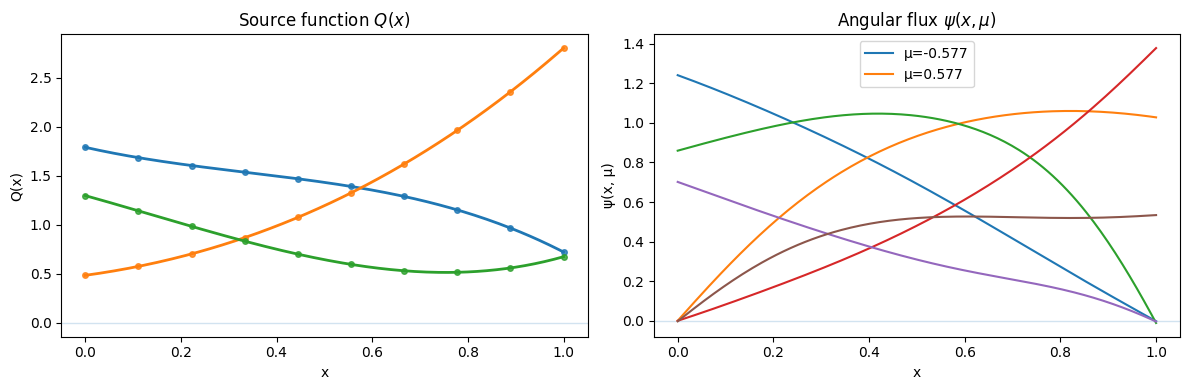

In [ ]:
model.eval()

n_plot = 3

# -------------------------------------------------
# 1. Sample ONE batch of source functions
# -------------------------------------------------
coeffs = torch.randn(n_plot, 4, device=device)

# branch input (Q at sensors)
f_sensors = eval_polynomial(coeffs, x_sensors).squeeze(-1)  # (n_plot, m)

# -------------------------------------------------
# 2. Domain grid
# -------------------------------------------------
x_plot = torch.linspace(0, 1, 200, device=device).view(-1, 1)

# expand for (x, mu)
x_in = x_plot.unsqueeze(0).unsqueeze(2).repeat(n_plot, 1, n_mu, 1)

mu_in = mus.view(1, 1, n_mu, 1).repeat(n_plot, 200, 1, 1)

# -------------------------------------------------
# 3. Forward prediction
# -------------------------------------------------
with torch.no_grad():
    psi_pred = model(f_sensors, x_in, mu_in)  # (n_plot, 200, n_mu, 1)

psi_pred = psi_pred.squeeze(-1).cpu().numpy()

x_plot_np = x_plot.squeeze(-1).cpu().numpy()

# sensor locations
x_sensors_np = x_sensors.squeeze(-1).cpu().numpy()

f_sensors_np = f_sensors.cpu().numpy()

# -------------------------------------------------
# 4. Plot
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -----------------------------
# Left: source Q(x)
# -----------------------------
axes[0].set_title("Source function $Q(x)$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Q(x)")
axes[0].axhline(0, linewidth=1, alpha=0.2)

x_dense = x_plot_np

Q_plot = eval_polynomial(coeffs, x_plot).squeeze(-1).cpu().numpy()

for i in range(n_plot):
    line, = axes[0].plot(x_dense, Q_plot[i], linewidth=2)

    axes[0].plot(
        x_sensors_np,
        f_sensors_np[i],
        "o",
        color=line.get_color(),
        markersize=4,
        alpha=0.8
    )

# -----------------------------
# Right: angular flux ψ(x, μ)
# -----------------------------
axes[1].set_title("Angular flux $\\psi(x, \\mu)$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("ψ(x, μ)")
axes[1].axhline(0, linewidth=1, alpha=0.2)

for i in range(n_plot):
    for j in range(n_mu):
        axes[1].plot(
            x_plot_np,
            psi_pred[i, :, j],
            label=f"μ={mus[j].item():.3f}" if i == 0 else None
        )

axes[1].legend()

plt.tight_layout()
plt.show()

# With Numerical data, $S_N$ Method

1D steady neutron transport equation without the scattering term\
\
$μ \frac{∂ψ(x, μ)}{∂x} + Σ_t​ ψ(x, μ) = Q(x)$


We are learning

$Q(x) ⟶ ψ(x,μ)$ for generic $Q(x)$

(Without scattering and scalar flux)

With numerical data using the $S_N$ Method

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")

[INFO] Using device: cpu


Problem Setup

We solve:

$μ \frac{∂ψ(x, μ)}{∂x} + Σ_t​ ψ(x, μ) = Q(x)$

WITHOUT scattering.

We use:
- $S_N$ discrete ordinates
- Classical transport sweeps to generate data
- Supervised DeepONet training

We learn the operator:

$Q(x) ⟶ ψ(x,μ)$

In [ ]:
L = 1.0
Nx = 100

x = np.linspace(0.0, L, Nx)
dx = x[1] - x[0]

# S2 quadrature
mus = np.array([
    -1.0 / np.sqrt(3),
     1.0 / np.sqrt(3)
])

n_mu = len(mus)

Sigma_t = 1.0

Random Source Functions

In [ ]:
def sample_polynomial_coeffs(
    batch_size,
    degree=3,
    scale=1.0
):
    return scale * np.random.randn(batch_size, degree + 1)

In [ ]:
def eval_polynomial_numpy(coeffs, x):
    """
    coeffs: (B, D+1)
    x: (N,)

    returns:
        (B, N)
    """

    B, D1 = coeffs.shape
    D = D1 - 1

    out = np.zeros((B, len(x)))

    for k in range(D + 1):
        out += coeffs[:, k:k+1] * (x[None, :] ** k)

    return out

$S_N$ Transport Solver (No Scattering)

In [ ]:
def solve_transport(Q):
    """
    Solve:

        μ dψ/dx + Σ_t ψ = Q(x)

    using upwind transport sweeps.

    Parameters
    ----------
    Q : (Nx,)

    Returns
    -------
    psi : (n_mu, Nx)
    """

    psi = np.zeros((n_mu, Nx))


    # Positive μ sweep
    mu = mus[1]

    psi_in = 0.0

    for i in range(Nx):

        denom = mu / dx + Sigma_t

        psi[1, i] = (
            Q[i] + (mu / dx) * psi_in
        ) / denom

        psi_in = psi[1, i]


    # Negative μ sweep
    mu = mus[0]

    psi_in = 0.0

    for i in reversed(range(Nx)):

        denom = abs(mu) / dx + Sigma_t

        psi[0, i] = (
            Q[i] + (abs(mu) / dx) * psi_in
        ) / denom

        psi_in = psi[0, i]

    return psi

Generate Dataset

In [ ]:
n_train = 2000
n_test = 200

m = 20

x_sensors = np.linspace(0, L, m)

print("[INFO] Generating training data...")

train_coeffs = sample_polynomial_coeffs(
    n_train,
    degree=3,
    scale=1.0
)

Q_train = eval_polynomial_numpy(train_coeffs, x)

Q_sensor_train = eval_polynomial_numpy(
    train_coeffs,
    x_sensors
)

# shape:
# (n_train, n_mu, Nx)
psi_train = np.zeros((n_train, n_mu, Nx))

for i in range(n_train):

    psi = solve_transport(Q_train[i])

    psi_train[i] = psi

    if (i + 1) % 200 == 0:
        print(f"Generated {i+1}/{n_train}")

print("[INFO] Generating test data...")

test_coeffs = sample_polynomial_coeffs(
    n_test,
    degree=3,
    scale=1.0
)

Q_test = eval_polynomial_numpy(test_coeffs, x)

Q_sensor_test = eval_polynomial_numpy(
    test_coeffs,
    x_sensors
)

psi_test = np.zeros((n_test, n_mu, Nx))

for i in range(n_test):

    psi = solve_transport(Q_test[i])

    psi_test[i] = psi

[INFO] Generating training data...
Generated 200/2000
Generated 400/2000
Generated 600/2000
Generated 800/2000
Generated 1000/2000
Generated 1200/2000
Generated 1400/2000
Generated 1600/2000
Generated 1800/2000
Generated 2000/2000
[INFO] Generating test data...


Convert to Torch

In [ ]:
Q_sensor_train = torch.tensor(
    Q_sensor_train,
    dtype=torch.float32
).to(device)

psi_train = torch.tensor(
    psi_train,
    dtype=torch.float32
).to(device)

Q_sensor_test = torch.tensor(
    Q_sensor_test,
    dtype=torch.float32
).to(device)

psi_test = torch.tensor(
    psi_test,
    dtype=torch.float32
).to(device)

x_tensor = torch.tensor(
    x.reshape(-1, 1),
    dtype=torch.float32
).to(device)

DeepONet

In [ ]:
class MLP(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden,
        output_dim
    ):

        super().__init__()

        layers = []

        prev = input_dim

        for h in hidden:

            layers += [
                nn.Linear(prev, h),
                nn.Tanh()
            ]

            prev = h

        layers += [nn.Linear(prev, output_dim)]

        self.net = nn.Sequential(*layers)


    def forward(self, x):

        return self.net(x)

class DeepONet(nn.Module):

    def __init__(
        self,
        m_sensors,
        p=64
    ):

        super().__init__()

        # Branch:
        # Q(x) at sensors
        self.branch = MLP(
            input_dim=m_sensors,
            hidden=[128, 128],
            output_dim=p
        )

        # Trunk:
        # (x, μ)
        self.trunk = MLP(
            input_dim=2,
            hidden=[128, 128],
            output_dim=p
        )

    def forward(
        self,
        f_sensors,
        x,
        mu
    ):
        """
        f_sensors : (B, m)

        x :
            (N, 1)

        mu :
            (n_mu,)

        Returns
        -------
        psi :
            (B, n_mu, N)
        """
        B = f_sensors.shape[0]
        N = x.shape[0]

        # --------------------------------------------
        # Branch
        # --------------------------------------------

        b = self.branch(f_sensors)
        # (B, p)

        # --------------------------------------------
        # Trunk input
        # --------------------------------------------

        x_rep = x.view(1, N, 1).repeat(B, 1, n_mu)

        mu_rep = torch.tensor(
            mu,
            dtype=torch.float32,
            device=device
        ).view(1, 1, n_mu).repeat(B, N, 1)

        xt = torch.stack([x_rep, mu_rep], dim=-1)

        xt = xt.view(B * N * n_mu, 2)

        # --------------------------------------------
        # Trunk
        # --------------------------------------------

        t = self.trunk(xt)

        t = t.view(B, N, n_mu, -1)

        # --------------------------------------------
        # Dot product
        # --------------------------------------------

        u = (
            t * b.unsqueeze(1).unsqueeze(2)
        ).sum(dim=-1)

        # (B, N, n_mu)

        return u.permute(0, 2, 1)


# ============================================================
# Model
# ============================================================

model = DeepONet(
    m_sensors=m,
    p=64
).to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

loss_fn = nn.MSELoss()

Training

In [ ]:
batch_size = 64
steps = 5000

print("[INFO] Training DeepONet...")

for step in range(1, steps + 1):

    idx = np.random.choice(
        n_train,
        batch_size,
        replace=False
    )

    batch_Q = Q_sensor_train[idx]

    batch_psi = psi_train[idx]

    pred = model(
        batch_Q,
        x_tensor,
        mus
    )

    loss = loss_fn(pred, batch_psi)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if step % 500 == 0 or step == 1:

        print(
            f"Step {step:5d} | "
            f"Loss = {loss.item():.5e}"
        )

[INFO] Training DeepONet...
Step     1 | Loss = 6.94353e-01
Step   500 | Loss = 2.31042e-03
Step  1000 | Loss = 4.39664e-04
Step  1500 | Loss = 1.26720e-03
Step  2000 | Loss = 1.76506e-03
Step  2500 | Loss = 5.20331e-04
Step  3000 | Loss = 1.60553e-03
Step  3500 | Loss = 3.44377e-04
Step  4000 | Loss = 7.56658e-04
Step  4500 | Loss = 1.49995e-04
Step  5000 | Loss = 2.54714e-04


Evaluation

In [ ]:
model.eval()

with torch.no_grad():

    pred_test = model(
        Q_sensor_test[:3],
        x_tensor,
        mus
    )

pred_test = pred_test.cpu().numpy()

psi_true = psi_test[:3].cpu().numpy()

Q_plot = Q_test[:3]

Visualization

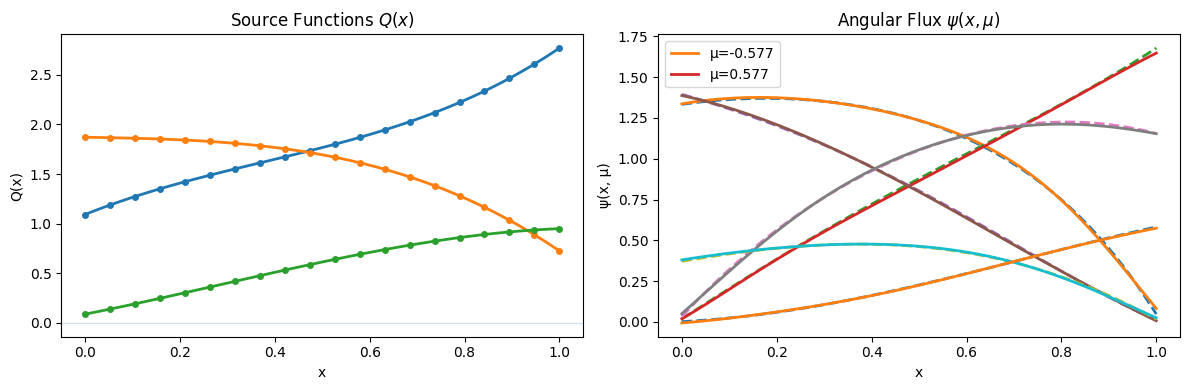

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

# Left: Source Functions

axes[0].set_title("Source Functions $Q(x)$")

axes[0].set_xlabel("x")

axes[0].set_ylabel("Q(x)")

axes[0].axhline(
    0,
    linewidth=1,
    alpha=0.2
)

for i in range(3):

    line, = axes[0].plot(
        x,
        Q_plot[i],
        linewidth=2
    )

    axes[0].plot(
        x_sensors,
        Q_sensor_test[i].cpu().numpy(),
        "o",
        color=line.get_color(),
        markersize=4
    )


# Right: Angular Flux

axes[1].set_title(
    "Angular Flux $\\psi(x, \\mu)$"
)

axes[1].set_xlabel("x")

axes[1].set_ylabel("ψ(x, μ)")

for i in range(3):

    for j in range(n_mu):

        # True
        axes[1].plot(
            x,
            psi_true[i, j],
            "--",
            linewidth=2
        )

        # Prediction
        axes[1].plot(
            x,
            pred_test[i, j],
            linewidth=2,
            label=(
                f"μ={mus[j]:.3f}"
                if i == 0 else None
            )
        )

axes[1].legend()

plt.tight_layout()